## Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [1]:
## leer fichero del mi pc
import pandas as pd
import kagglehub
#df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
import os
# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
print("Path to dataset files:", path)

file_path = os.path.join(path, "amz_uk_price_prediction_dataset.csv")
df = pd.read_csv(file_path)

Path to dataset files: C:\Users\menot\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [2]:
df.head()


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [4]:
import pandas as pd
import matplotlib.pyplot as plt # viz
import seaborn as sns # better viz
import numpy as np # numerical python

%matplotlib inline
pd.set_option('display.max_columns', None)


1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [5]:
import pandas as pd

# 1. Generate a frequency table for the product 'category'
category_frequencies = df['category'].value_counts()

# Display the top 5 most listed product categories
top_5_categories = category_frequencies.head(5)

print("--- Frequency Table (Top 10 to see the context) ---")
print(category_frequencies.head(10))
print("\n--- Top 5 Most Listed Product Categories ---")
print(top_5_categories)

--- Frequency Table (Top 10 to see the context) ---
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64

--- Top 5 Most Listed Product Categories ---
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

C:\Users\menot\AppData\Local\Temp\ipykernel_20204\1249247841.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_categories.values, y=top_15_categories.index, palette="viridis")


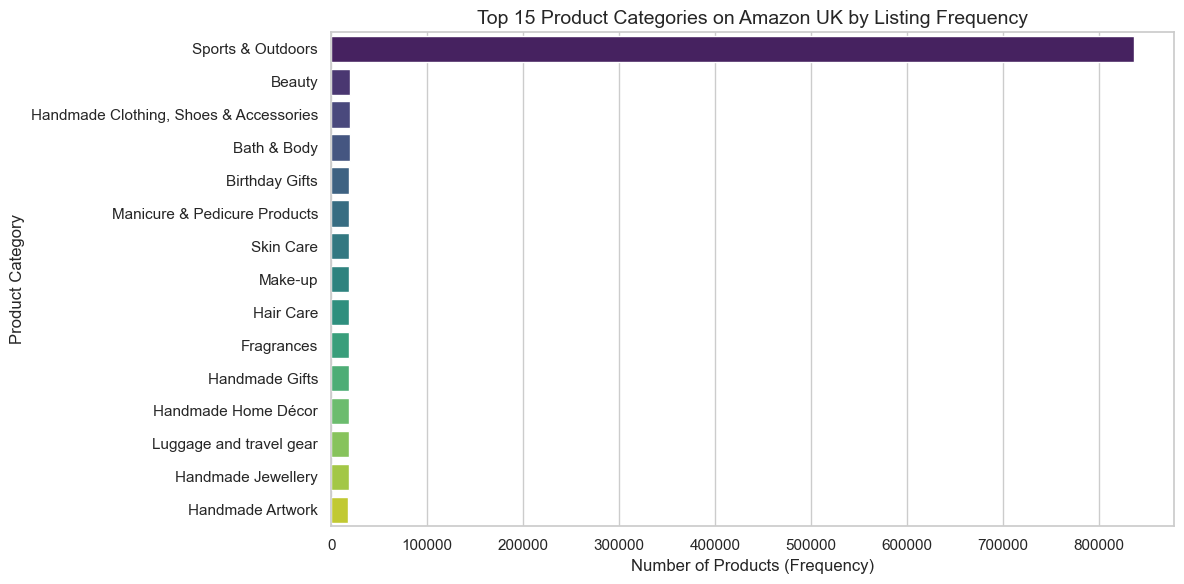

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Since the dataset has 2.4 million rows and likely hundreds of categories, 
# plotting all of them will make the chart unreadable. 
# We will use the top 15 categories for a clean visualization.
top_15_categories = df['category'].value_counts().head(15)

# Set the figure size and style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

#  bar chart
sns.barplot(x=top_15_categories.values, y=top_15_categories.index, palette="viridis")

plt.title('Top 15 Product Categories on Amazon UK by Listing Frequency', fontsize=14)
plt.xlabel('Number of Products (Frequency)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

plt.tight_layout()
plt.show()

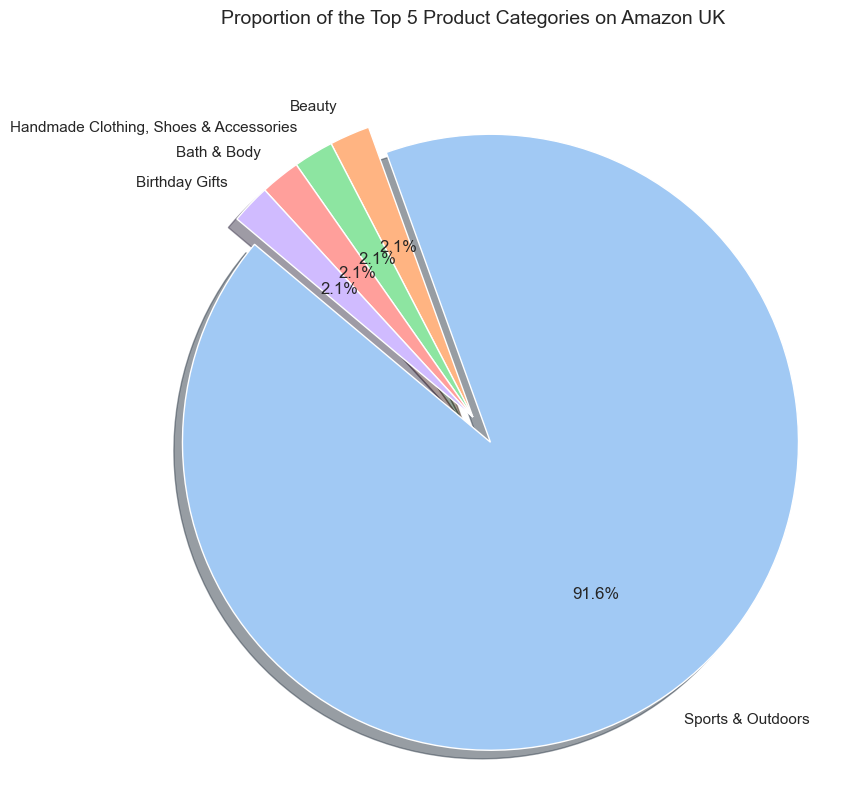

In [8]:
# Select the top 5 categories to avoid a cluttered pie chart
top_5_for_pie = df['category'].value_counts().head(5)

# Set the figure size
plt.figure(figsize=(10, 10))

# Define colors and visual properties
colors = sns.color_palette('pastel')[0:5]
explode = (0.1, 0, 0, 0, 0)  # "Explode" the 1st slice to highlight the most dominant category

# pie chart
plt.pie(top_5_for_pie, 
        labels=top_5_for_pie.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode,
        shadow=True)

plt.title('Proportion of the Top 5 Product Categories on Amazon UK', fontsize=14)
plt.show()

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

Bussiness Question: 
The mean (average) is significantly higher than the mode and median. This is because the mean is very sensitive to extreme values ​​(for example, if laptops or jewelry cost thousands of pounds, the mean will be distributed higher). However, the mode (the most common price) reflects typical Amazon psychological pricing strategies, likely showing a low value like £9.99 or £12.99.

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [9]:
# Calculate mean, median, and mode for the 'price' column
price_mean = df['price'].mean()
price_median = df['price'].median()

# The mode() method returns a pandas Series, so we extract the first element [0]
price_mode = df['price'].mode()[0]

print("--- Measures of Centrality: Product Price ---")
print(f"Mean (Average) Price: £{price_mean:.2f}")
print(f"Median Price: £{price_median:.2f}")
print(f"Mode (Most Common) Price: £{price_mode:.2f}")

--- Measures of Centrality: Product Price ---
Mean (Average) Price: £89.24
Median Price: £19.09
Mode (Most Common) Price: £9.99


- What's the average price point of products listed? How does this compare with the most common price point (mode)?
Mean(Average price) = £89.24
Mode (Most Common) Price: £9.99

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [10]:
# Calculate variance and standard deviation
price_variance = df['price'].var()
price_std_dev = df['price'].std()

# Calculate the range (Maximum - Minimum)
price_min = df['price'].min()
price_max = df['price'].max()
price_range = price_max - price_min

# Calculate the Interquartile Range (IQR = Q3 - Q1)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print("--- Measures of Dispersion: Product Price ---")
print(f"Price Variance: {price_variance:.2f}")
print(f"Price Standard Deviation: £{price_std_dev:.2f}")
print(f"Price Range: £{price_range:.2f} (From £{price_min} to £{price_max})")
print(f"Interquartile Range (IQR): £{IQR:.2f}")

--- Measures of Dispersion: Product Price ---
Price Variance: 119445.49
Price Standard Deviation: £345.61
Price Range: £100000.00 (From £0.0 to £100000.0)
Interquartile Range (IQR): £36.00


 - How varied are the product prices? Are there any indicators of a significant spread in prices?
 The results indicate a massive dispersion (a very significant spread), a very high range (from penny-for-penny products to thousands-of-pound products), and a very large standard deviation. This confirms that Amazon's catalog is extremely heterogeneous and that prices are not tightly clustered around the mean.

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

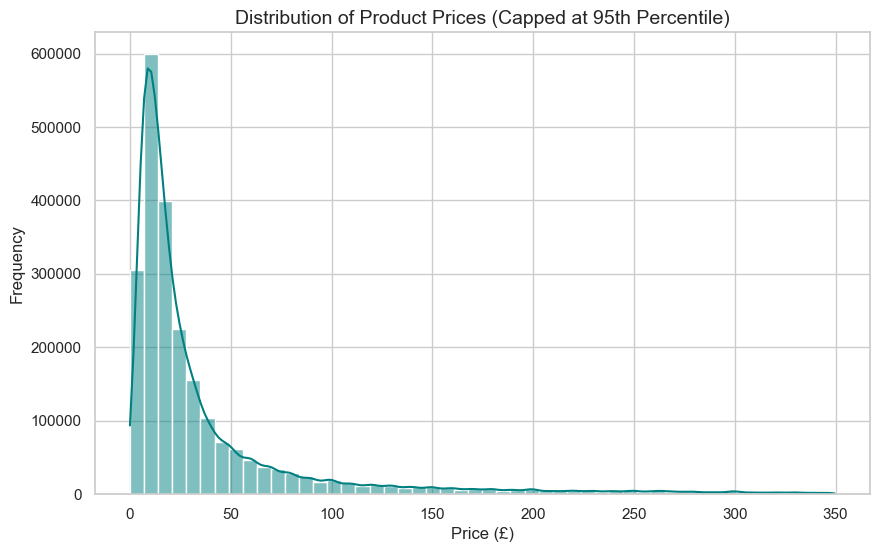

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# THE PROBLEM: If we plot the raw data, the extreme outliers will crush the chart
# sns.histplot(df['price'], bins=100) -> This would be unreadable!

# THE SOLUTION: We filter the data to only show up to the 95th percentile.
# This removes the extreme extreme luxury items and lets us see where the bulk of products fall.
price_95th_percentile = df['price'].quantile(0.95)
typical_prices = df[df['price'] <= price_95th_percentile]['price']

# Create the histogram with the filtered data
sns.histplot(typical_prices, bins=50, color='teal', kde=True)

plt.title('Distribution of Product Prices (Capped at 95th Percentile)', fontsize=14)
plt.xlabel('Price (£)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

##### THE PROBLEM: 
If we plot the raw data, the extreme outliers will crush the chart
sns.histplot(df['price'], bins=100) -> This would be unreadable!

##### THE SOLUTION: 
We filter the data to only show up to the 95th percentile.
This removes the extreme extreme luxury items and lets us see where the bulk of products fall.

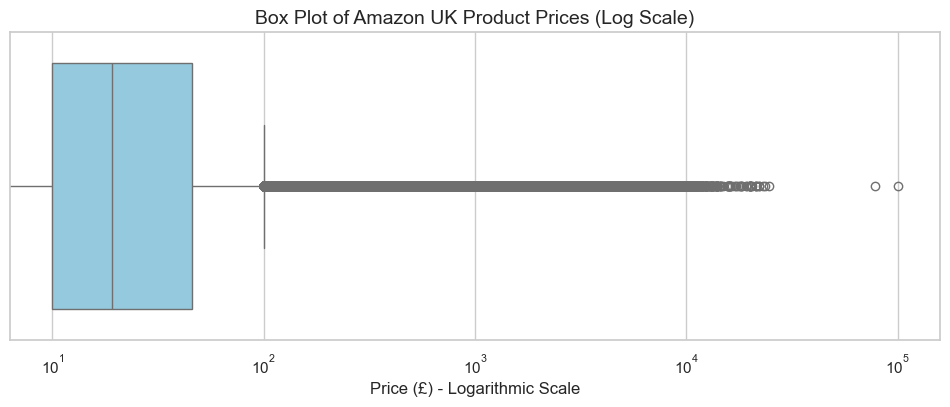

In [12]:
plt.figure(figsize=(12, 4))

# Create a box plot for the raw price data
sns.boxplot(x=df['price'], color='skyblue')

plt.title('Box Plot of Amazon UK Product Prices (Log Scale)', fontsize=14)

# We apply a logarithmic scale to the X-axis. 
# Without it, the box (IQR) would be crushed into a single vertical line due to extreme outliers.
plt.xscale('log')
plt.xlabel('Price (£) - Logarithmic Scale', fontsize=12)

plt.show()

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

In [13]:
# Calculate mean, median, and mode for the 'stars' column (ratings)
stars_mean = df['stars'].mean()
stars_median = df['stars'].median()

# Extract the first mode
stars_mode = df['stars'].mode()[0]

print("--- Measures of Centrality: Product Ratings (Stars) ---")
print(f"Mean (Average) Rating: {stars_mean:.2f}")
print(f"Median Rating: {stars_median:.2f}")
print(f"Mode (Most Common) Rating: {stars_mode:.2f}")

--- Measures of Centrality: Product Ratings (Stars) ---
Mean (Average) Rating: 2.15
Median Rating: 0.00
Mode (Most Common) Rating: 0.00


The most common trend on Amazon UK isn't having good or bad reviews, but having no reviews at all. For a business, the real initial challenge on this platform isn't getting 5 stars, but breaking the "0" barrier and getting that first review that gives the product visibility.

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

In [14]:
# Calculate variance and standard deviation for 'stars'
stars_variance = df['stars'].var()
stars_std_dev = df['stars'].std()

# Calculate the Interquartile Range (IQR = Q3 - Q1)
Q1_stars = df['stars'].quantile(0.25)
Q3_stars = df['stars'].quantile(0.75)
IQR_stars = Q3_stars - Q1_stars

print("--- Measures of Dispersion: Product Ratings (Stars) ---")
print(f"Rating Variance: {stars_variance:.2f}")
print(f"Rating Standard Deviation: {stars_std_dev:.2f}")
print(f"Interquartile Range (IQR): {IQR_stars:.2f}")

--- Measures of Dispersion: Product Ratings (Stars) ---
Rating Variance: 4.82
Rating Standard Deviation: 2.19
Interquartile Range (IQR): 4.40


The ratings are completely inconsistent; they're totally polarized. The Amazon UK marketplace operates at extremes: either your product falls into the "black hole" of 0 stars (no one has rated or bought it), or it skyrockets to 4.5-5 stars if it manages to gain traction and visibility. There's virtually no middle ground.

For a business, this demonstrates that the market doesn't punish with mediocre ratings (2 or 3 stars), but with complete silence (0 stars). Once a product gains traction, the natural progression is to receive very high ratings.

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [15]:
# Calculate skewness and kurtosis using pandas built-in methods
stars_skewness = df['stars'].skew()
stars_kurtosis = df['stars'].kurtosis()

print("--- Shape of the Distribution: Product Ratings (Stars) ---")
print(f"Skewness: {stars_skewness:.2f}")
print(f"Kurtosis: {stars_kurtosis:.2f}")

--- Shape of the Distribution: Product Ratings (Stars) ---
Skewness: 0.08
Kurtosis: -1.93


The ratings are anything but normal. The reason the asymmetry is almost zero (symmetrical) isn't because most products have the average rating (2.15), but because the market is divided into two massive blocks that balance each other out:

The gigantic block of ignored products with 0 stars (as we saw in the mode and median).

The enormous block of successful products accumulating 4 and 5-star ratings.

For a business, this demonstrates that the Amazon marketplace is an "all or nothing" environment (boom or bust). The middle valley (2- or 3-star products) is practically empty. Either your product is nonexistent for consumers, or it's a resounding success.

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

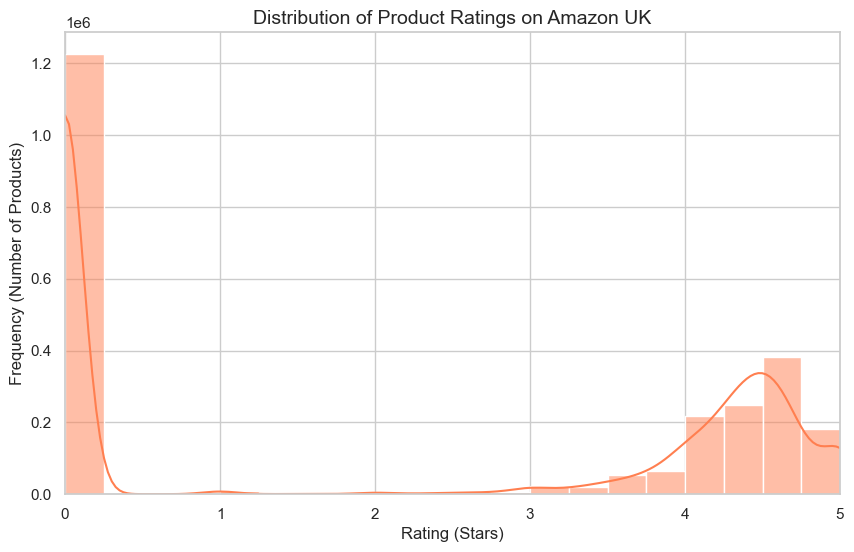

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Create a histogram with a KDE (Kernel Density Estimate) curve
sns.histplot(df['stars'], bins=20, color='coral', kde=True)

plt.title('Distribution of Product Ratings on Amazon UK', fontsize=14)
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Frequency (Number of Products)', fontsize=12)

# Set the x-axis limits from 0 to 5 since ratings cannot exceed this range
plt.xlim(0, 5)

plt.show()

- 0 stars (no reviews) is the most common rating, followed by 4-5 stars range. This highlights the extreme polarization in customer feedback on Amazon UK, where products either go unnoticed or receive overwhelmingly positive reviews.

**Submission**:

Business-Centric Summary for Ratings:

Our EDA reveals a strong positive bias in Amazon UK product ratings. The distribution is heavily left-skewed (negative skewness), with the overwhelming majority of products receiving ratings between 4.0 and 5.0. The low standard deviation confirms this consistency. For a business, this implies that achieving a 4-star rating is not a mark of excellence, but rather the bare minimum standard to remain competitive in the marketplace. Products dipping below 4.0 stars will likely struggle severely, as they fall outside the consumer expectation norm.